# Defoliation Statistics
Calculate minimum anomaly for each year and calculate the proportion of cells in outbreak, the probability of remaining in outbreak, and length of outbreak.

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import rasterio
from pathlib import Path
from tqdm.notebook import tqdm

## Analysis Parameters

In [49]:
# Image dataset
imageset = '../data/images_MtPleasant/'

# Model fit dataset
modelset = '../data/MtPleasant.pkl'

# Data save location
save_csv = '../data/results_MtPleasant/median_anom_summer_2019.csv'

# Image save location
save_image = '../data/results_MtPleasant/median_anom_summer_2019.png'

# Analysis year
year = 2019

## Load Data

In [3]:
# get the filenames for all tif files
data_path = Path(imageset) 
file_list = np.array(sorted(list(data_path.glob('*.tif'))))

# an open list to store data array
da_list = []

for filename in file_list:
    date = filename.name.split('T')[0] # get rid of .tif
    date = date[0:4] + '-' + date[4:6] + '-' + date[6:8] # Put into ISO format
    with rasterio.open(filename, 'r') as src:
        im = src.read()
        # read image into ndarray

        # transpose the matrix from (band, row, col) to (row, col, band)
        im = np.transpose(im, [1,2,0])

        # set null values
        im[im == 0.] = np.nan

        # get coordinates
        # first axis, from north to south
        lat_array = np.linspace(src.bounds[3],src.bounds[1],im.shape[0])
        # second axis, from west to east
        lon_array = np.linspace(src.bounds[0],src.bounds[2],im.shape[1])

        src.close()
        
        da = xr.Dataset({'EVI':(('lat','lon'),im[:,:,0]), 'NIRv':(('lat','lon'),im[:,:,1])},
                        coords={'lat':lat_array,'lon':lon_array})
        
        # add time dimension
        da = da.expand_dims('time')
        da.coords['time'] = [np.datetime64(date)]
        
        # append the data array to da_list
        
        da_list.append(da)

images = xr.merge(da_list)
models = pd.read_pickle(modelset)

## Analysis

In [39]:
# Extract day of year and year information from system index
def add_doy_year(df):
    safe_df = df.copy()
    
    safe_df['Year'] = safe_df['time'].map(lambda x: x.year)
    safe_df['doy'] = safe_df['time'].map(lambda x: x.timetuple().tm_yday)
    return safe_df

# Normalizes data within year
def normalize_VI(df, band):
    safe_df = df.copy()
    transformed = safe_df[['Year', band]]
    
    safe_df[f'{band}_nrml'] = transformed.groupby(['Year']).transform(lambda x: (x - x.min())/(x.max() - x.min()))[band]
    return safe_df

# Predict based on pwlf
def model_predict(intercepts, slopes, breaks, value):
    if value < breaks[0]:
        return slopes[0]*value + intercepts[0]
    for i in range(len(breaks)-1):
        if breaks[i] <= value and value < breaks[i+1]:
            return slopes[i]*(value) + intercepts[i]
    return slopes[-1]*value + intercepts[-1]

# Statistics/Defoliation Indices
def min_anom(df):
    return df['EVI_anom'].min()

def min_summer_anom(df):
    mask = (df['doy'] >= 150) & (df['doy'] <= 250)
    return df.loc[mask, 'EVI_anom'].min()

def mean_summer_anom(df):
    mask = (df['doy'] >= 150) & (df['doy'] <= 250)
    return df.loc[mask, 'EVI_anom'].mean()

def median_summer_anom(df):
    mask = (df['doy'] >= 150) & (df['doy'] <= 250)
    return df.loc[mask, 'EVI_anom'].median()

In [40]:
def process_point(dataset, latitude, longitude, year, stat_func = min_anom):
    # Paramters for analysis
    band = 'EVI'
    
    df = dataset.isel(lat=latitude, lon=longitude).to_pandas().reset_index().dropna()
    if len(df) == 0:
        return np.nan
    
    # Extract day of year and year information from system index
    df = add_doy_year(df)
    
    year_mask = df['Year'] >= 2019
    df = df.loc[year_mask]
    
    # Normalizes data within year
    df = normalize_VI(df, band)
    
    mask = (models['lat'] == latitude) & (models['lon'] == longitude)
    intercepts = models.loc[mask, 'intercepts'].iloc[0]
    slopes = models.loc[mask, 'slopes'].iloc[0]
    breaks = models.loc[mask, 'breaks'].iloc[0]
    
    # Calculate anomaly
    df['EVI_pred'] = df['doy'].map((lambda x: model_predict(intercepts, slopes, breaks, x)))
    df['EVI_anom'] = df['EVI_nrml'] - df['EVI_pred']
    
    # Record minimum anomaly for specified year
    mask = (df['Year'] == year)
    
    return median_summer_anom(df.loc[mask])

In [50]:
defol = pd.DataFrame(columns = ['lat', 'lon', 'stat'])
x_length = images.sizes['lon']
y_length = images.sizes['lat']


with tqdm(total = x_length*y_length) as pbar:
    for y in range(y_length):
        for x in range(x_length):
            stat = process_point(images, y, x, year)
            defol.loc[len(defol.index)] = [y, x, stat]
            pbar.update(1)

  0%|          | 0/8892 [00:00<?, ?it/s]

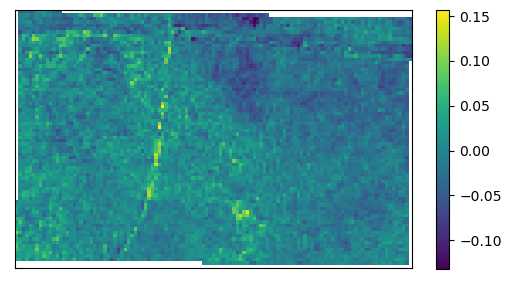

In [51]:
defol.to_csv(save_csv)
defol_pivot = (defol).pivot(index = 'lat', columns = 'lon')
plt.imshow(defol_pivot * -1)
plt.colorbar(shrink = 0.7)
plt.xticks([])
plt.yticks([])
plt.savefig(save_image)

In [ ]:
mask = defol['stat'] < -3
defol.loc[mask]

In [ ]:
models.iloc[1873]

In [ ]:
df = add_doy_year(images.isel(lat = 16, lon = 1).to_pandas().reset_index())

In [ ]:
mask = (models['lat'] == 16) & (models['lon'] == 1)
intercepts = models.loc[mask, 'intercepts'].iloc[0]
slopes = models.loc[mask, 'slopes'].iloc[0]
breaks = models.loc[mask, 'breaks'].iloc[0]

x_grid = [x for x in range(63, 365)]
y_pred = [model_predict(intercepts, slopes, breaks, x) for x in x_grid]
plt.plot(df['doy'], df['EVI'], 'o')
plt.plot(x_grid, y_pred)

In [ ]:
model_predict(intercepts, slopes, breaks, 4)